# Sensor Placement in Multi-Region Problems Using EIM, GEIM, and the Parameterized Background Data-Weak (PBDW) Approach

In practical sensor placement applications, it is often impossible to install sensors in certain regions, for example, within solid domains. This tutorial demonstrates how to use pyforce for multi-region cases through the ReadFromOFMultiRegion class to import multi-region mesh, field and to restrict sensor placement region.

The tutorial applies the EIM, GEIM, and Parameterized Background Data–Weak (PBDW) approaches, following the methodology introduced in the tutorial “03_sensor_placement”.
The test case considered here is a Pressurized Water Reactor (PWR) pin cell consisting of three regions:Fuel, Cladding and Coolant.


By completing this tutorial, you will learn:

    How to read both region-based data and full-model data, including importing field "prec0" (non-zore value in the 'FUEL' region, and uniform zeros in both "CLAD" and "COOL" regions); field "U" (only values in the 'COOL' region)
    How to restrict sensor placement to specific regions using the EIM, GEIM, and SGreedy algorithms

Data and Geometry

The dataset used in this tutorial focuses on the fast neutron flux, generated by the author. The geometric model is based on: https://doi.org/10.1016/j.nucengdes.2023.112164. with the axial length reduced to 0.5 m for computational convenience.

## Instantiate ReadFromOFMultiRegion

First, let's import the ReadFromOFMultiRegion class from the pyforce module and instantiate it. Here, we directly read from processor* decomposed files, switching decomposed_case to 'True'. This way can avoid "reconstructPar" operation in OpenFOAM, saving cost.

In [1]:
import warnings
warnings.filterwarnings("default")

from pyforce.tools.write_read import ReadFromOFMultiRegion

# Class instantiation
of = ReadFromOFMultiRegion('/mnt/d/WorkingDirectory_PhD/Data/Document/paper/Journal/solver/data/pwr_pin/github_tutorial/new_trans',decomposed_case=True,skip_zero_time=True)

Case Type decomposed


## Import Multi-Region Mesh and Visualization

This part aims to import the mesh for both the full model and selected subregions, and visualizes them using the Plotter class provided by pyvista.

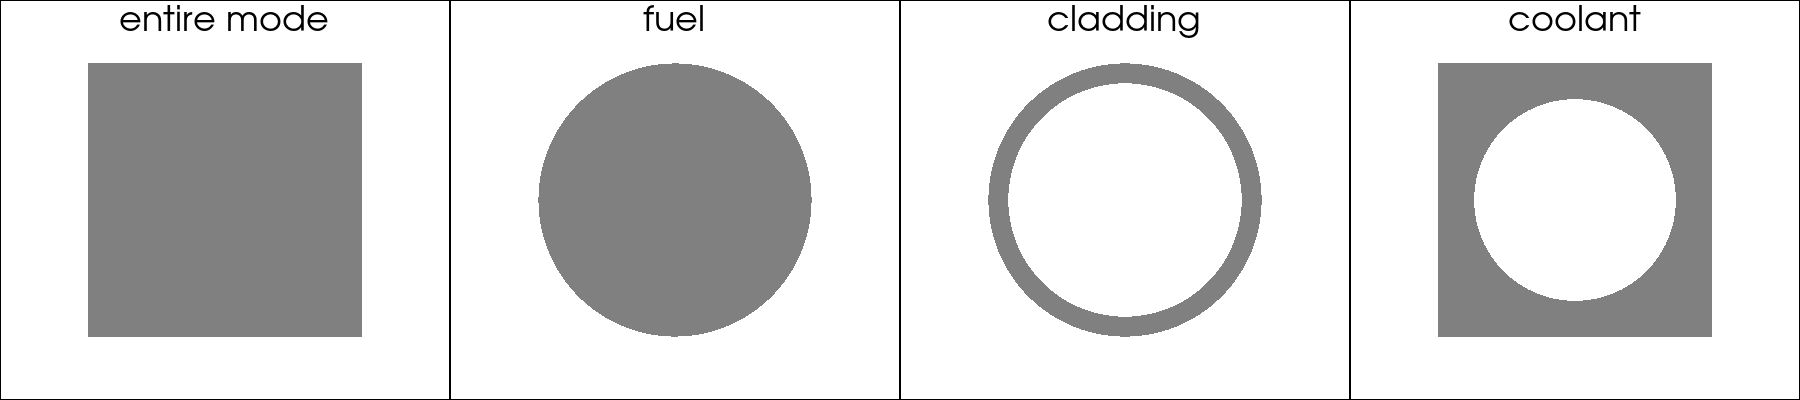

In [2]:
import pyvista as pv

'''
# define a function to draw the mid-plane slice
def draw_geo_slize(mesh) -> None:
    slice_z = mesh.slice(normal='z', origin=grid.center)
    pl = pv.Plotter()
    pl.add_mesh(slice_z, show_edges=True, color='white', opacity=0.5)
    pl.view_xy()
    pl.show(jupyter_backend='static')

#draw_geo_slize(cool_grid)
'''

# import mesh
grid = of.mesh(decomposed_mode=True)
fuel_grid = of._region_mesh('FUEL',decomposed_mode=True)
clad_grid = of._region_mesh('CLAD',decomposed_mode=True)
cool_grid = of._region_mesh('COOL',decomposed_mode=True)

# fuel_grid = of.mesh(['FUEL'])
# clad_grid = of.mesh(['CLAD'])
# cool_grid = of.mesh(['COOL'])
#grid.plot(show_edges=True)

# print mesh, either by plot function (3D), or pyvista class
figs = 4
figs_title = ['entire mode','fuel','cladding','coolant']
pl = pv.Plotter(shape = (1,figs),window_size=(1800, 400))
for i,mesh in enumerate([grid,fuel_grid,clad_grid,cool_grid]):
    slice_z = mesh.slice(normal='z', origin=grid.center)
    pl.subplot(0, i)
    pl.add_mesh(slice_z, show_edges=True, color='white', opacity=0.5)
    pl.view_xy()
    pl.add_text(
        figs_title[i],
        position="upper_edge",
        font_size=14,
        color="black"
    )
pl.show(jupyter_backend='static')


## Import Multi-Region Field

In this section, we can choose to import a field for a specific region at a given time, or import the field for all regions. It is important to note that some fields are only meaningful in certain regions. For example, the velocity field exists only in fluid regions. The ReadFromOFMultiRegion class provides the function _get_valid_regions_for_field to determine the valid regions associated with a given field. Here, we test this functionality using the flux0 field.

To import a specific field, the available import_mode includes: 'pyvista', 'fluidfoam' and 'foamlib'. For multi-region case, three methods currently only support to importing cell data. After testing, we found that for multi-region cases, the efficiency for three modes are as follows: 'foamlib' > 'fluidfoam' > 'pyvista' (not recommended for multi-region cases). 

### Flux0

In [3]:
field = 'flux0'

times = of._get_time_directories() # snapshots time points
allRegions_snap, times = of.import_field(field,regions_to_import=['CLAD','COOL','FUEL'], import_mode='foamlib')
clad_snap, times = of.import_field(field, regions_to_import='CLAD', import_mode='foamlib')
cool_snap, times = of.import_field(field, regions_to_import='COOL', import_mode='foamlib')
fuel_snap, times = of.import_field(field, regions_to_import='FUEL', import_mode='foamlib')

Valid_flux0_region = of._get_valid_regions_for_field(field)
print("\nThe valid region for flux0: ", Valid_flux0_region)

Importing flux0 from all regions - foamlib: 3.000 / 3.00 - 13.283293 s/it
Importing flux0 from all regions - foamlib: 1.000 / 1.00 - 0.000087 s/it
Importing flux0 from all regions - foamlib: 1.000 / 1.00 - 0.000186 s/it
Importing flux0 from all regions - foamlib: 1.000 / 1.00 - 0.000080 s/it

The valid region for flux0:  ['CLAD', 'COOL', 'FUEL']


### Visualize Multi-Region Flux0 Field

Here, we define a function to extract a slice at the mid-plane.

To verify that the field has been successfully imported, this section visualizes the fast neutron flux (flux0) on the mid-plane slice using matplotlib.pyplot. is important to note that, compared to the Plotter class provided by pyvista, matplotlib.pyplot performs automatic interpolation. Therefore, masks are applied to restrict the visualization to the target region. It is recommended to use Plotter for complex geometries, while matplotlib.pyplot is suitable for simpler cases.

In [4]:
import numpy as np
import pyvista as pv

def get_slice_data(grid: pv.UnstructuredGrid, snap, origin=None):
    if origin is None:
        origin = grid.center

    g = grid.copy()
    g.cell_data["fun"] = snap

    g = g.clean()

    g = g.cell_data_to_point_data()
    slc = g.slice(normal="z", origin=origin)

    data = slc.point_data["fun"]
    return slc.points, data, np.min(data), np.max(data)

/home/lyt/anaconda3/envs/pyforce-env/lib/python3.10/site-packages/matplotlib/tri/_triangulation.py:181: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


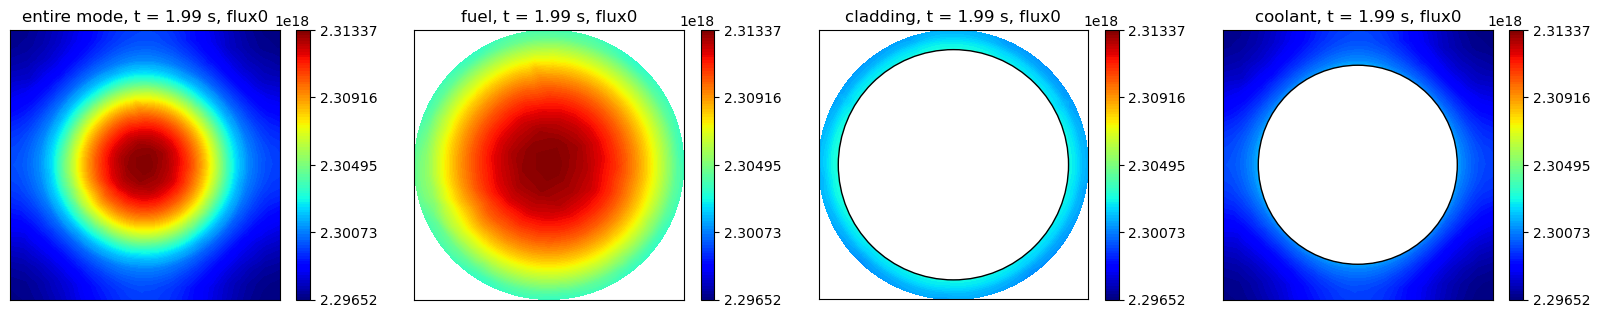

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# initialize
nrows = 1
ncols = 4
tt = len(times)-2 # the last second snapshot
t = 1.99 # s
figs_title = ['entire mode','fuel','cladding','coolant']
fig, axs = plt.subplots(nrows=1, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows))

# circles for mask
c1 = Circle((0.0, 0.0), radius=0.0041, edgecolor='black', facecolor='white', linewidth=1) # fuel radius
c2 = Circle((0.0, 0.0), radius=0.0048, edgecolor='black', facecolor='white', linewidth=1) # clad radius

# get slice data
allRegion_sliced_points, allRegion_sliced_data, allRegion_slice_min, allRegion_slice_max = get_slice_data(grid, allRegions_snap[tt])
fuel_sliced_points, fuel_sliced_data, fuel_slice_min, fuel_slice_max = get_slice_data(fuel_grid, fuel_snap[tt])
clad_sliced_points, clad_sliced_data, clad_slice_min, clad_slice_max = get_slice_data(clad_grid, clad_snap[tt])
cool_sliced_points, cool_sliced_data, cool_slice_min, cool_slice_max = get_slice_data(cool_grid, cool_snap[tt])

c = axs[0].tricontourf(allRegion_sliced_points[:, 0], allRegion_sliced_points[:, 1], allRegion_sliced_data, levels=np.linspace(allRegion_slice_min, allRegion_slice_max, 100), cmap='jet')
c = axs[1].tricontourf(fuel_sliced_points[:, 0], fuel_sliced_points[:, 1], fuel_sliced_data, levels=np.linspace(allRegion_slice_min, allRegion_slice_max, 100), cmap='jet')
c = axs[2].tricontourf(clad_sliced_points[:, 0], clad_sliced_points[:, 1], clad_sliced_data, levels=np.linspace(allRegion_slice_min, allRegion_slice_max, 100), cmap='jet')
axs[2].add_patch(c1) # mask for cladding 
c = axs[3].tricontourf(cool_sliced_points[:, 0], cool_sliced_points[:, 1], cool_sliced_data, levels=np.linspace(allRegion_slice_min, allRegion_slice_max, 100), cmap='jet')
axs[3].add_patch(c2) # mask for coolant

for i in range(nrows*ncols):
    axs[i].set_title(f'{figs_title[i]}, t = {t} s, flux0')
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_aspect('equal', 'box')
    fig.colorbar(c, ax=axs[i], ticks = np.linspace(allRegion_slice_min, allRegion_slice_max, 5))


### Import prec0

Field prec0 only exists in the "FUEL" region, whereas it is a uniform value of 0 in the "CLAD" and "COOL" regions. import_field function assigns the uniform value to all cells in these two regions.

In [6]:
prec0_snap, times = of.import_field('prec0', import_mode='foamlib')

Valid_prec0_region = of._get_valid_regions_for_field('prec0')
print("\nThe valid region for prec0: ", Valid_prec0_region)

Importing prec0 from all regions - foamlib: 3.000 / 3.00 - 10.834257 s/it

The valid region for prec0:  ['CLAD', 'COOL', 'FUEL']


/home/lyt/anaconda3/envs/pyforce-env/lib/python3.10/site-packages/matplotlib/tri/_triangulation.py:181: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


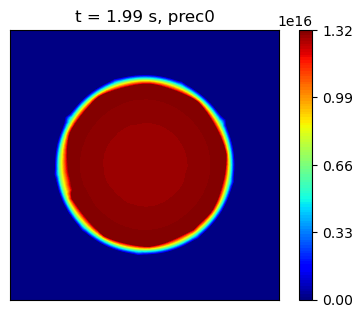

In [7]:
# visualize
nrows = 1
ncols = 1

fig, axs = plt.subplots(nrows=1, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows))

# get slice data
allRegion_sliced_points_prec0, allRegion_sliced_data_prec0, allRegion_slice_min_prec0, allRegion_slice_max_prec0 = get_slice_data(grid, prec0_snap[tt])

c = axs.tricontourf(allRegion_sliced_points_prec0[:, 0], allRegion_sliced_points_prec0[:, 1], allRegion_sliced_data_prec0, levels=np.linspace(allRegion_slice_min_prec0, allRegion_slice_max_prec0, 100), cmap='jet')

axs.set_title(f't = {t} s, prec0')
axs.set_xticks([])
axs.set_yticks([])
axs.set_aspect('equal', 'box')
fig.colorbar(c, ax=axs, ticks = np.linspace(allRegion_slice_min_prec0, allRegion_slice_max_prec0, 5))

### Import U

Field U only exists in the "COOL" region.

In [8]:
U_snap, times = of.import_field('U', import_mode='foamlib')

Valid_U_region = of._get_valid_regions_for_field('U')
print("\nThe valid region for U: ", Valid_U_region)

Importing U from all regions - foamlib: 1.000 / 1.00 - 0.000088 s/it

The valid region for U:  ['COOL']


##### Convert U to magnitude
At present, the rose-pyforce does not support the vector quantity.

In [9]:
from pyforce.tools.functions_list import FunctionsList

data_dofs = int((U_snap[0].flatten().shape[0])/3)
U_magnitude = FunctionsList(dofs=data_dofs)

for ii in range(len(times)):
    U = U_snap[ii].reshape(cool_grid.n_cells, 3)
    U = np.linalg.norm(U, axis=1)
    U_magnitude.append(U)

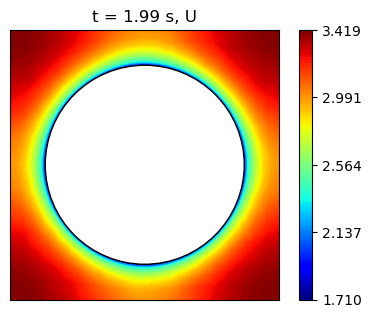

In [10]:
# visualize
nrows = 1
ncols = 1

fig, axs = plt.subplots(nrows=1, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows))

# get slice data
allRegion_sliced_points_U, allRegion_sliced_data_U, allRegion_slice_min_U, allRegion_slice_max_U = get_slice_data(cool_grid, U_magnitude[tt])

c = axs.tricontourf(allRegion_sliced_points_U[:, 0], allRegion_sliced_points_U[:, 1], allRegion_sliced_data_U, levels=np.linspace(allRegion_slice_min_U, allRegion_slice_max_U, 100), cmap='jet')

c0 = Circle((0.0, 0.0), radius=0.0048, edgecolor='black', facecolor='white', linewidth=1) # clad radius
axs.add_patch(c0) # mask for coolant

axs.set_title(f't = {t} s, U')
axs.set_xticks([])
axs.set_yticks([])
axs.set_aspect('equal', 'box')
fig.colorbar(c, ax=axs, ticks = np.linspace(allRegion_slice_min_U, allRegion_slice_max_U, 5))

## Splitting Dataset

After importing the field, this section prepares the data, either using the train_test_split function for random splitting, or through a user-defined method.

In [37]:
from pyforce.tools.functions_list import train_test_split

times = times
snaps = allRegions_snap
train_params, test_params, train_dataset, test_dataset = train_test_split(times, snaps, test_size=0.2, random_state=42)

## Define Candidate Points for Sensor Placement

As the training is based on the entire model, this section focuses on selecting specific candidate points or within the specific candidate region. It is important to note that the EIM approach relies on the candidate index, whereas the GEIM and SGreedy approaches are based on candidate coordinates.

#### Fixed region ('COOL') for sensor placement

In [68]:
from pyforce.tools.write_read import get_candidate_regions

candidate_points, candidate_idx = get_candidate_regions(grid,cool_grid)

#### Visualise fixed region for sensor placement

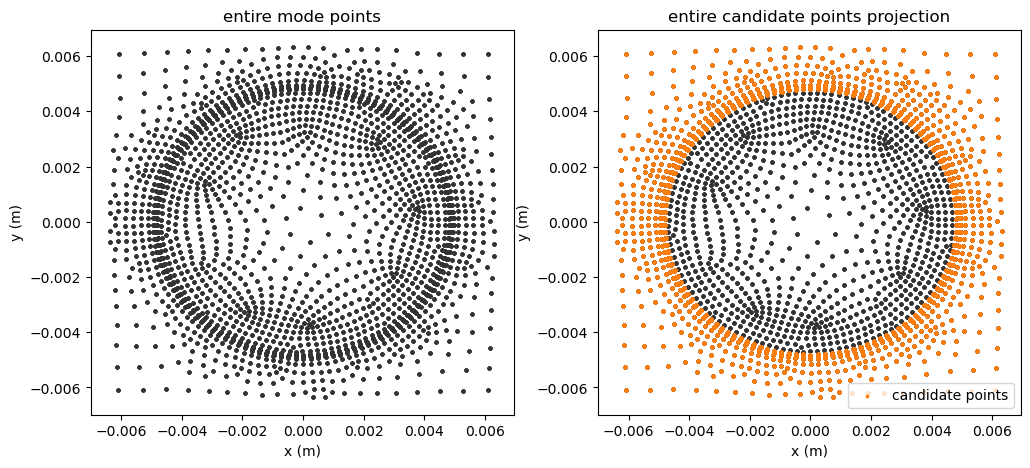

In [69]:
points = grid.cell_centers().points
nodes_cool = points[candidate_idx]

fig, axs = plt.subplots(1,2, figsize=(6*2,5))

figs_title = ['entire mode points', 'entire candidate points projection']
for i,ax in enumerate(axs):
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    axs[i].set_title(figs_title[i])
mark_size = 3

axs[0].scatter([p[0] for p in points], [p[1] for p in points], color="#333333", s=mark_size)

axs[1].scatter([p[0] for p in points], [p[1] for p in points], color="#333333", s=mark_size)
axs[1].scatter(nodes_cool[:,0], nodes_cool[:,1], color="#ff7f0e", s=mark_size,label='candidate points')
axs[1].legend()

#### Fixed the points for sensor placement (e.g. according to the sensor installation)

In [70]:
candidate = []
candidate.append([-0.005,-0.005,0.1])
candidate.append([0.005,-0.005,0.1])
candidate.append([-0.005,0.005,0.1])
candidate.append([0.005,0.005,0.1])

from pyforce.tools.write_read import get_candidate_probes

candidate_fixed_points, candidate_fixed_idx = get_candidate_probes(grid, cool_grid, candidate)
nodes_fixed_point = points[candidate_fixed_idx]

#### Visualise fixed points for sensor placement

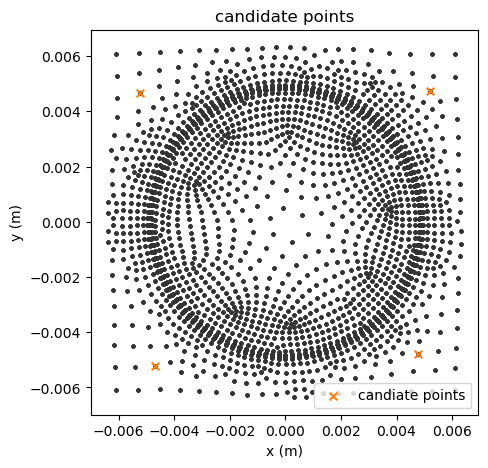

In [71]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('candidate points')
mark_size = 3

ax.scatter([p[0] for p in points], [p[1] for p in points], color="#333333", s=mark_size)
ax.scatter(nodes_fixed_point[:,0], nodes_fixed_point[:,1], color="#ff7f0e", s=30, marker='x', label='candiate points')
ax.legend()


#### Fixed channels for sensor placement
The tol parameter is tuned according to the different geometric discretisation.

In [72]:
from pyforce.tools.write_read import get_candidate_channel_all_points

candidate_1 = []
candidate_1.append([-0.005,-0.005])
candidate_points_1, candidate_idx_1 = get_candidate_channel_all_points(grid, cool_grid, candidate_1, tol = 3.5e-4)
candidate_2 = []
candidate_2.append([-0.005,0.005])
candidate_points_2, candidate_idx_2 = get_candidate_channel_all_points(grid, cool_grid, candidate_2, tol = 3.5e-4)
candidate_3 = []
candidate_3.append([0.005,-0.005])
candidate_points_3, candidate_idx_3 = get_candidate_channel_all_points(grid, cool_grid, candidate_3, tol = 3.5e-4)
candidate_4 = []
candidate_4.append([0.005,0.005])
candidate_points_4, candidate_idx_4 = get_candidate_channel_all_points(grid, cool_grid, candidate_4, tol = 3e-4)

candidate_channel_idx = np.concatenate((candidate_idx_1,candidate_idx_2,candidate_idx_3,candidate_idx_4))
candidate_channel_points = grid.cell_centers().points[candidate_channel_idx]

#### Visualise fixed channels for sensor placemnet

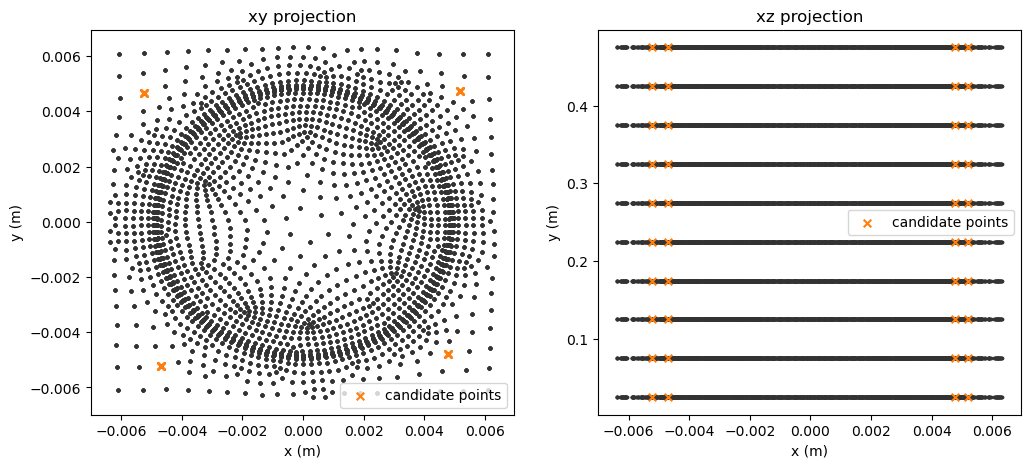

In [73]:
fig, axs = plt.subplots(1,2, figsize=(6*2,5))

figs_title = ['xy projection', 'xz projection']
for i,ax in enumerate(axs):
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    axs[i].set_title(figs_title[i])
mark_size = 3

axs[0].scatter(points[:,0], points[:,1], color="#333333", s=mark_size)
axs[0].scatter(candidate_channel_points[:,0], candidate_channel_points[:,1], color="#ff7f0e", s=30, marker='x',label='candidate points')
axs[0].legend()

axs[1].scatter(points[:,0],points[:,2], color="#333333", s=mark_size)
axs[1].scatter(candidate_channel_points[:,0], candidate_channel_points[:,2], color="#ff7f0e", s=30, marker='x',label='candidate points')
axs[1].legend()

## Offline Stage

After obtaining the candidate indices and points, this section performs the offline-stage training, following the procedures introduced in the tutorial “03_sensor_placement”. The placement constraints are specified via the _xm_idx argument for EIM and the xm_list argument for GEIM. These parameters are restricted to the coolant region.

In [74]:
# initialize
#=======================
Mmax = 10
gdim = 3
s = 1e-3
#======================

# EIM
from pyforce.offline.eim import EIM

eim_offline = EIM(grid, gdim=gdim, varname=field)
train_eim_coeffs = eim_offline.fit(train_snaps=train_dataset, Mmax = Mmax, 
                                   _xm_idx = candidate_idx, 
                                   verbose=True)[1]
# GEIM
from pyforce.offline.geim import GEIM
geim_offline = GEIM(grid, gdim=gdim, varname=field, sensors_type='Gaussian')
sens_params = {
    's': s, # spread of the Gaussian kernels - hyperparameter to be tuned according to the physical system
    'xm_list': candidate_points # downsampled candidate points for computational efficiency
}
train_geim_coeff = geim_offline.fit(train_snaps=train_dataset, Mmax = Mmax, 
                                    sensor_params=sens_params, verbose=True)[2]

  Iteration 010 | Abs Err (Linfty): 8.79e+13 - EIM done
Creating Gaussian Sensor Library: 100.000 / 100.00% - 0.000568 s/it


The SGreedy algorithm is a greedy method generalized to any reduced basis and any linear functional used as a sensor. In particular, SGreedy requires a reduced basis spanning an associated reduced space as input. This basis can, for example, be obtained via a POD of the training snapshots. Sensors are then selected to maximize the information provided, spanning an update space of dimension Mmax.

To this end, we perform a randomized SVD of the training snapshots.

SVD of flux0 snapshots calculated in 21.998515 seconds (cpu).


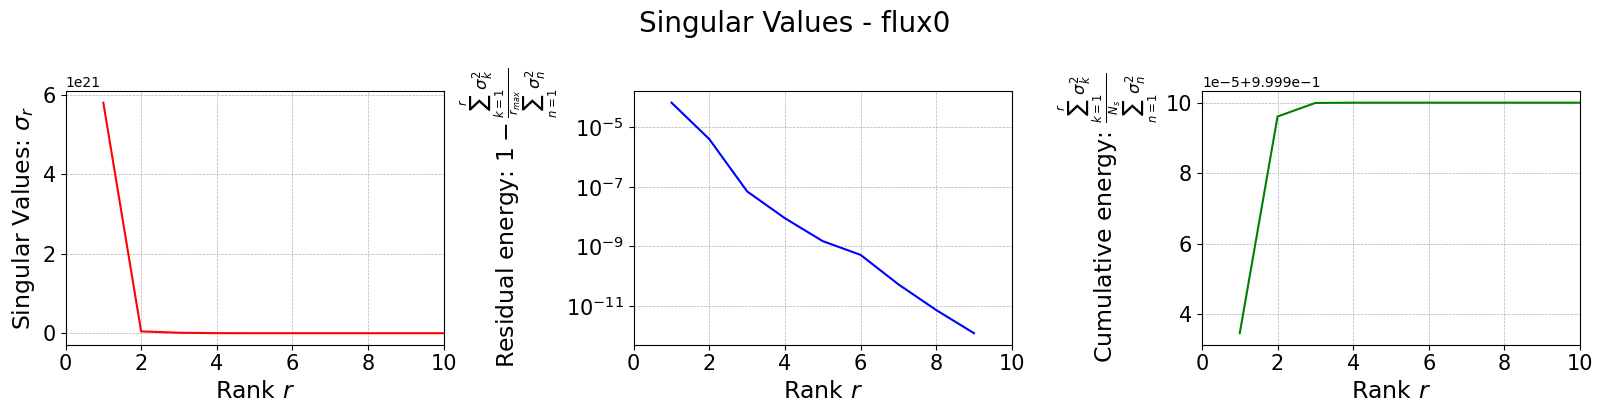

In [75]:
from pyforce.offline.pod import rSVD

svd_offline = rSVD(grid, gdim=gdim, varname=field)
svd_offline.fit(train_snaps=train_dataset, rank=Mmax, verbose=True)

svd_fig = svd_offline.plot_sing_vals()
axs = svd_fig.get_axes()
for ax in axs:
    ax.set_xlim(0,Mmax)

Once the basis is computed, we can use it to perform the SGreedy sensor placement. The initialization of the class is similar to the previous cases.

The training of the SGreedy algorithm, through the fit method, requires the basis functions spanning the reduced space (using only the first 5 modes), the maximum number of sensors to be placed, and the sensor parameters (similar to the GEIM case).

In [77]:
# PBDW
from pyforce.offline.sgreedy import SGREEDY
sgreedy_placement = SGREEDY(grid, gdim=gdim, varname=field)

sens_params = {
    's': s, # spread of the Gaussian kernels - hyperparameter to be tuned according to the physical system
    'xm_list': candidate_points, # downsampled candidate points for computational efficiency
}

rank_svd = 5 + 1

sgreedy_placement.fit(
    basis_functions= svd_offline.svd_modes[:rank_svd],
    Mmax = Mmax,
    sensor_params=sens_params
)

Creating Gaussian Sensor Library: 100.000 / 100.00% - 0.000510 s/it


### Visualize Sensor Placement

Once the basis is computed, it can be used to perform SGreedy sensor placement. The initialization of the class is similar to the previous cases.

Training the SGreedy algorithm via the fit method requires the basis functions spanning the reduced space (using only the first five modes), the maximum number of sensors to be placed, and the sensor parameters (similar to the GEIM case).

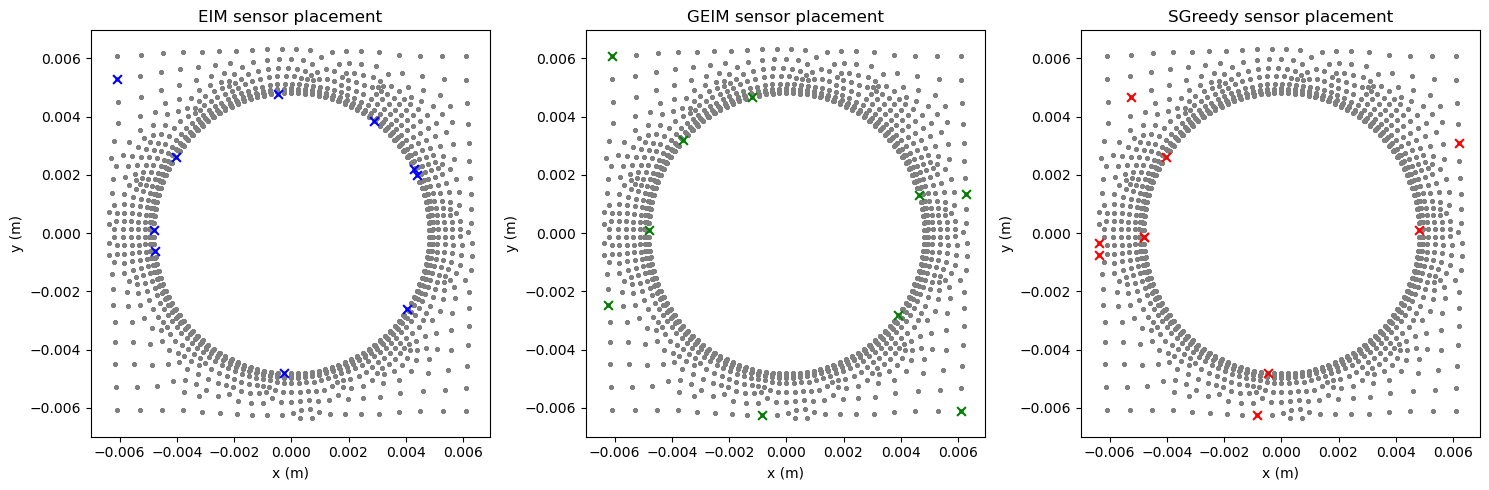

In [78]:
# compare the placement
fig, axs = plt.subplots(1,3, figsize=(15,5))
markersize = 40

for ax in axs:
    ax.scatter(cool_grid.cell_centers().points[:,0], cool_grid.cell_centers().points[:,1], marker='o', color='0.5', s=5); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

axs[0].scatter([p[0] for p in eim_offline.magic_points['points']], [p[1] for p in eim_offline.magic_points['points']], marker='x', color='b', s=markersize, label='EIM magic points')

axs[1].scatter([grid.cell_centers().points[geim_offline.magic_sensors.library(pp).argmax(), 0] for pp in range(len(geim_offline.magic_sensors))], [grid.cell_centers().points[geim_offline.magic_sensors.library(pp).argmax(), 1] for pp in range(len(geim_offline.magic_sensors))], marker='x', color='g', s=markersize, label='GEIM magic points')

axs[2].scatter([p[0] for p in sgreedy_placement.sensor_centers], [p[1] for p in sgreedy_placement.sensor_centers], marker='x', color='r', s=markersize, label='SGreedy sensors')

axs[0].set_title('EIM sensor placement'); axs[1].set_title('GEIM sensor placement'); axs[2].set_title('SGreedy sensor placement')

plt.tight_layout()

Furthermore, since our case involves a 3D geometry, this section visualizes the distribution of all sensors for the GEIM approach; the other two approaches are omitted to save space.

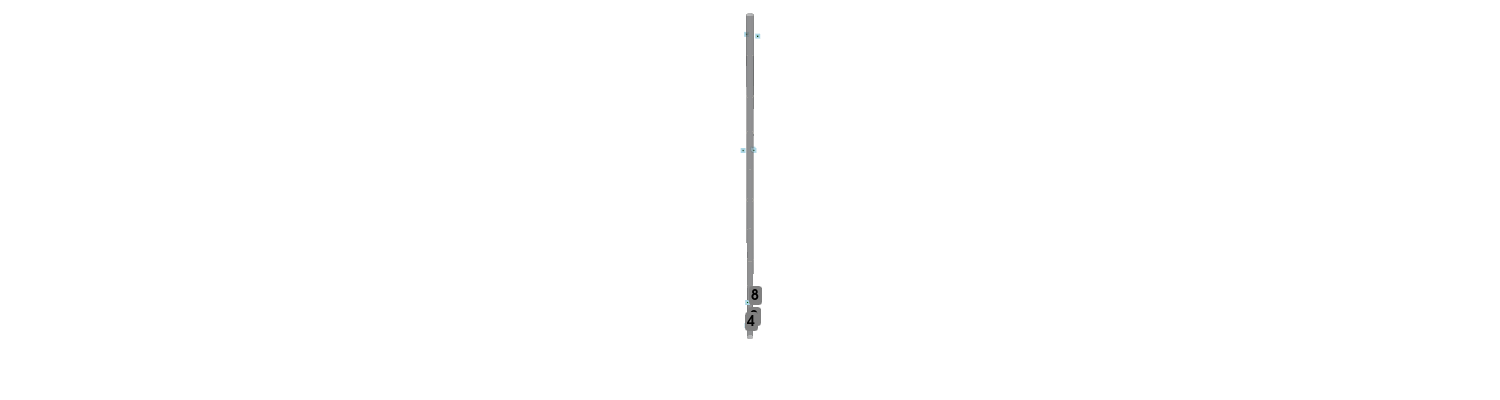

In [79]:
# sensor nodes
nodes = geim_offline.magic_sensors.nodes
max_idx = np.argmax(geim_offline.magic_sensors.library.return_matrix(), axis=0)[:Mmax]

pl = pv.Plotter(window_size=[1500, 400])
pl.add_mesh(of._region_mesh('CLAD'), color='white', show_edges=False, opacity=0.3)  # grid

# add sensor scatter
for ii in range(len(max_idx)):
    idx = max_idx[ii]
    pl.add_mesh(
        pv.Sphere(radius=0.001, center=nodes[idx]),  # using sphere
        color='green'
    )
    pl.add_point_labels(
        points=np.array([nodes[idx]]),       # 2d array
        labels=[str(ii + 1)],                # number label
        font_size=14,
        text_color='black',
        point_color=None,                    # none mark, only number
        point_size=0
    )

pl.show(jupyter_backend='ipyvtklink')


## Online Stage

In this section, we perform online-stage training using the EIM, GEIM, and PBDW approaches.

In [80]:
#Online stage
noise_std = 0.001*allRegions_snap.mean()

# EIM
from pyforce.online.eim import EIM as OnlineEIM

eim_online = OnlineEIM(grid, gdim=gdim, varname=field)
eim_online.set_basis(eim_offline.magic_functions)
eim_online.set_magic_points(eim_offline.magic_points)

# Assemble Tikhonov regularization matrix
eim_online.set_tikhonov_matrices(beta_coeffs=train_eim_coeffs)

# Prediction with EIM
test_eim_measures = eim_online.get_measurements(test_dataset, noise_std=noise_std)
eim_prediction = eim_online.estimate(test_eim_measures, regularization_params={'type': 'tikhonov', 'lambda': noise_std**2})

# GEIM
from pyforce.online.geim import GEIM as OnlineGEIM

geim_online = OnlineGEIM(grid, gdim=gdim, varname=field)
geim_online.set_basis(geim_offline.magic_functions)
geim_online.set_magic_sensors(geim_offline.magic_sensors.library)

# Assemble Tikhonov regularization matrix
geim_online.set_tikhonov_matrices(beta_coeffs=train_geim_coeff)

# Prediction with GEIM
test_geim_measures = geim_online.get_measurements(test_dataset, noise_std=noise_std)
geim_prediction = geim_online.estimate(test_geim_measures, regularization_params={'type': 'tikhonov', 'lambda': noise_std**2})

# PBDW
from pyforce.online.pbdw import PBDW
pbdw_online = PBDW(grid, gdim=gdim, varname=field)
pbdw_online.set_basis(svd_offline.svd_modes[:rank_svd])
pbdw_online.set_basis_sensors(sgreedy_placement.sensors.library)

pbdw_online.compute_matrices()
pbdw_measures = pbdw_online.get_measurements(test_dataset, noise_std=noise_std)
pbdw_prediction = pbdw_online.estimate(pbdw_measures, xi=100)

## Comparison of Average Relative Error

We compare the results obtained using the three approaches: EIM, GEIM, and PBDW.

Computing errors: 80.000 / 80.00 - 0.000176 s/it


Text(0, 0.5, 'Average relative error')

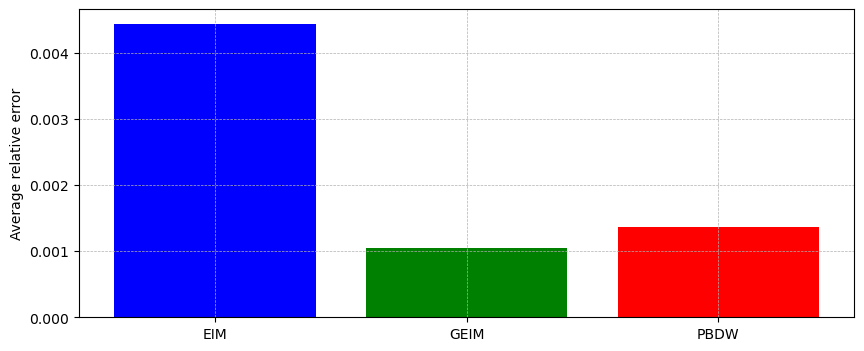

In [81]:
# Comparison of average relative errors
from pyforce.tools.backends import IntegralCalculator, LoopProgress
errors = {
    'EIM': [],
    'GEIM': [],
    'PBDW': []
}

calculator = IntegralCalculator(grid, gdim=gdim)
bar = LoopProgress(final=len(test_dataset), msg='Computing errors')

for mu, snap in enumerate(test_dataset):
    _snap_norm = calculator.L2_norm(snap)

    # EIM error
    errors['EIM'].append(
        calculator.L2_norm(snap - eim_prediction[mu]) / _snap_norm
    )

    # GEIM error
    errors['GEIM'].append(
        calculator.L2_norm(snap - geim_prediction[mu]) / _snap_norm
    )

    # PBDW error
    errors['PBDW'].append(
        calculator.L2_norm(snap - pbdw_prediction[mu]) / _snap_norm
    )

    bar.update(1)

fig, axs = plt.subplots(figsize=(10,4))
axs.bar(errors.keys(), [np.mean(errors[key]) for key in errors.keys()], 
        color=['blue', 'green', 'red'])
axs.grid(True, which='both', linestyle='--', linewidth=0.5)
axs.set_ylabel('Average relative error')